# 04 — Recommendation explorer: similarity, archetypes, failure modes

Metrics say the model is good; this notebook asks whether it *behaves* well. Using the served config trained on all interactions (as the API does), we look at three things qualitatively:

1. **Item-item similarity** — the 'fans also like' view of the learned artist embedding (the most Spotify-relevant capability).
2. **User archetypes** — do recommendations match distinct tastes?
3. **Failure modes** — popularity bias and the niche-listener problem the model card warns about, made concrete.

This is exploratory: no metric is computed, nothing is logged. It supports the claims in [`docs/specs/model_card.md`](../docs/specs/model_card.md).

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
from src import data_loading as dl, als_model, plotting as viz
from src.harness import search_config

viz.set_style()
FIG = project_root / 'outputs' / 'figures'
cfg = dict(search_config.CONFIG)

im = dl.build_interaction_matrix(dl.load_user_artists())
model, conf = als_model.train_als(im.matrix, factors=cfg['factors'], regularization=cfg['regularization'],
                                  iterations=cfg['iterations'], alpha=cfg['alpha'], seed=0)
artist_name = dl.load_artists().set_index('id')['name'].to_dict()

def col_name(col):
    return artist_name.get(int(im.item_ids[int(col)]), f'artist {int(col)}')

# name -> matrix column, among artists actually present in the matrix
present = {col_name(c).lower(): c for c in range(im.matrix.shape[1])}
def find_col(name):
    if name.lower() in present:
        return present[name.lower()]
    hits = [c for n, c in present.items() if name.lower() in n]
    return hits[0] if hits else None

print(f'served config: {cfg["factors"]} factors, alpha={cfg["alpha"]} | {im.matrix.shape[0]} users, {im.matrix.shape[1]} artists')

2026-06-30 18:32:47 | INFO    | data_loading | Loaded 92,834 interactions from user_artists.dat


served config: 32 factors, alpha=1.0 | 1892 users, 17632 artists


## 1. 'Fans also like' — item-item similarity

ALS learns an artist vector per artist. Cosine-nearest neighbours in that space are the 'more like this' recommendations — built from co-listening, with no genre labels given.

In [2]:
for seed in ['Radiohead', 'Lady Gaga', 'Metallica', 'Daft Punk', 'Johnny Cash']:
    col = find_col(seed)
    if col is None:
        continue
    ids, _ = als_model.similar_items(model, col, n=8)
    print(f'Fans of {col_name(col)} also like:')
    print('   ' + ', '.join(col_name(i) for i in ids))
    print()

Fans of Radiohead also like:
   The Beatles, Sigur Rós, The Cure, Pink Floyd, Muse, Bloc Party, Placebo, Arctic Monkeys

Fans of Lady Gaga also like:
   Britney Spears, Katy Perry, Rihanna, Ke$ha, Christina Aguilera, Beyoncé, Avril Lavigne, Madonna

Fans of Metallica also like:
   Iron Maiden, System of a Down, Black Sabbath, Guns N' Roses, Megadeth, AC/DC, Judas Priest, Black Label Society

Fans of Daft Punk also like:
   Gorillaz, deadmau5, Justice, Danger, BT, The Rapture, The Chemical Brothers, Informant

Fans of Johnny Cash also like:
   Duane Eddy, Dale Hawkins, The Strangeloves, Hoyt Johnson, Billy J. Kramer & The Dakotas, Arty Hill and the Long Gone Daddys, Bernie Early, The Riptones



### The embedding in 2D — does it organise by genre on its own?

If those neighbourhoods are real, the latent space should cluster by genre globally, not just locally. Project the 32-dimensional ALS artist vectors to 2D with PCA and colour the top artists by their dominant genre tag (the tags are used only for colouring, never for training).

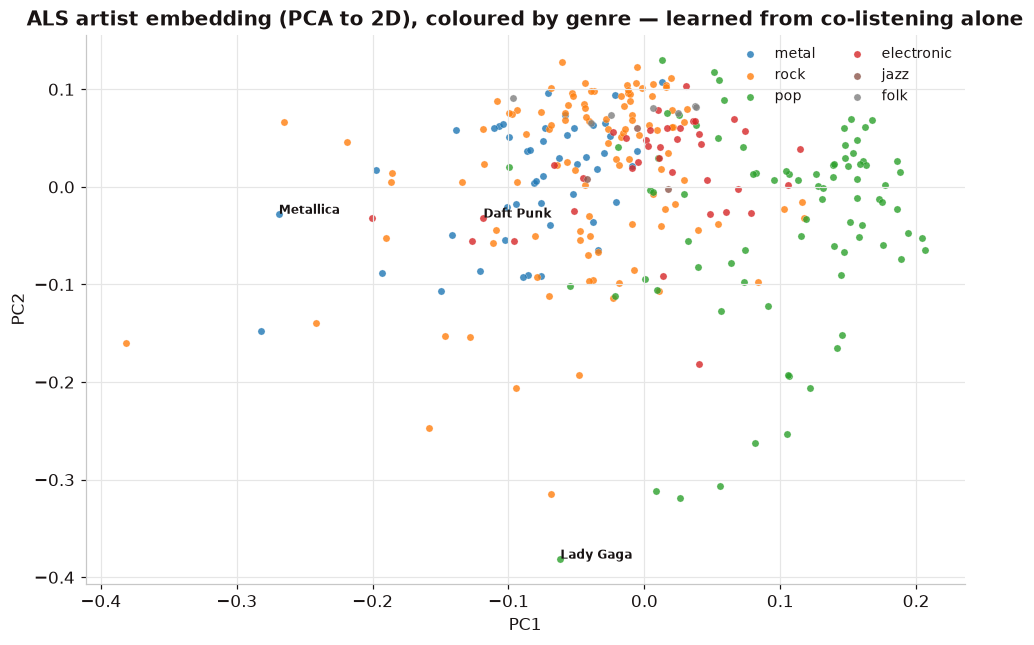

plotted 285 top artists carrying a genre tag


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from src import content

# dominant genre tag per artist (tags used for colour only, never for training)
ta = content.load_tag_assignments()
tag_vals = pd.read_csv(project_root / 'data' / 'raw' / 'tags.dat',
                       sep='\t', encoding='latin-1').set_index('tagID')['tagValue']
dom_tag = (ta.groupby(['artistID', 'tagID']).size().reset_index(name='c')
           .sort_values('c', ascending=False).drop_duplicates('artistID')
           .set_index('artistID')['tagID'])
GENRES = ['metal', 'rock', 'pop', 'electronic', 'hip hop', 'jazz', 'classical', 'folk']

def genre_of(artist_id):
    tid = dom_tag.get(artist_id)
    v = str(tag_vals.get(tid, '')).lower() if tid is not None else ''
    return next((g for g in GENRES if g in v), None)

listeners = np.asarray((im.matrix > 0).sum(axis=0)).ravel()
top = np.argsort(listeners)[::-1][:500]
gen = [genre_of(int(im.item_ids[c])) for c in top]
keep = [i for i, g in enumerate(gen) if g is not None]
cols = top[keep]; labels = [gen[i] for i in keep]

# PCA to 2D via SVD (no sklearn)
F = model.item_factors[cols].astype(float)
F = F - F.mean(axis=0)
U, S, _ = np.linalg.svd(F, full_matrices=False)
xy = U[:, :2] * S[:2]

fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.get_cmap('tab10')
for j, g in enumerate(GENRES):
    m = [i for i, x in enumerate(labels) if x == g]
    if m:
        ax.scatter(xy[m, 0], xy[m, 1], s=22, color=cmap(j), label=g, alpha=0.8, edgecolor='white', linewidth=0.2)
for name in ['Radiohead', 'Metallica', 'Daft Punk', 'Lady Gaga', 'Miles Davis', 'Johnny Cash']:
    c = find_col(name)
    if c is not None and c in set(cols.tolist()):
        idx = int(np.where(cols == c)[0][0])
        ax.annotate(name, (xy[idx, 0], xy[idx, 1]), fontsize=8, fontweight='bold')
ax.legend(frameon=False, ncol=2, fontsize=9)
ax.set(title='ALS artist embedding (PCA to 2D), coloured by genre — learned from co-listening alone',
       xlabel='PC1', ylabel='PC2')
fig.tight_layout(); fig.savefig(FIG / 'artist_embedding_2d.png'); plt.show()
print(f'plotted {len(cols)} top artists carrying a genre tag')

The neighbourhoods are coherent by genre and era despite the model never seeing a genre tag — evidence the latent space captured real structure.

## 2. User archetypes

Pick users with distinct tastes and inspect their top artists vs their recommendations.

In [4]:
rng = np.random.default_rng(7)
sample_users = rng.choice(im.matrix.shape[0], size=3, replace=False)
for u in sample_users:
    row = im.matrix.getrow(int(u))
    top_known = row.indices[np.argsort(row.data)[::-1][:6]]
    recs, _ = als_model.recommend_for_user(model, conf, int(u), n=8)
    print(f'user row {u}')
    print('   listens to : ' + ', '.join(col_name(c) for c in top_known))
    print('   recommended: ' + ', '.join(col_name(c) for c in recs))
    print()

user row 1785
   listens to : Converge, Angelo Badalamenti, Terror, Ray, Beirut, Beneath the Massacre
   recommended: Muse, Radiohead, Gorillaz, Dave Gahan, Björk, Martin L. Gore, The Prodigy, Blur

user row 1182
   listens to : Britney Spears, Madonna, Lady Gaga, Cher, Girls Aloud, Jeffree Star
   recommended: Spice Girls, Katy Perry, Shakira, Alanis Morissette, Avril Lavigne, Sugababes, BoA, Natasha Bedingfield

user row 1294
   listens to : The 13th Sign, Rialto, Lux, Dubstar, Paul Oakenfold, Soft Cell
   recommended: The Cure, New Order, Moby, Massive Attack, Pet Shop Boys, Duran Duran, Placebo, a-ha



## 3. Failure mode: popularity bias

Like all collaborative filtering, the model leans on popular artists. Quantify it: for every user's top-10 recommendations, where do the recommended artists sit in the popularity distribution (0 = most popular, 1 = most obscure)?

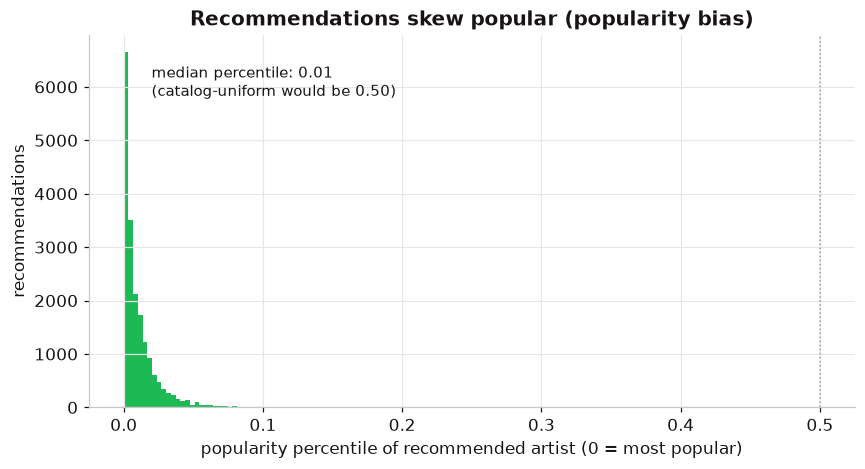

100% of all recommendations come from the most-popular 10% of artists.


In [5]:
import matplotlib.pyplot as plt
listeners = np.asarray((im.matrix > 0).sum(axis=0)).ravel()
# popularity percentile of each item: 0 = most popular
pop_rank = np.argsort(np.argsort(-listeners)) / (len(listeners) - 1)
all_recs = als_model.recommend_top_n(model, conf, np.arange(im.matrix.shape[0]), n=10)
rec_pct = pop_rank[all_recs.ravel()]

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.hist(rec_pct, bins=40, color=viz.GREEN)
ax.axvline(0.5, color=viz.MUTED, ls=':', lw=1)
ax.set(title='Recommendations skew popular (popularity bias)',
       xlabel='popularity percentile of recommended artist (0 = most popular)', ylabel='recommendations')
ax.text(0.02, ax.get_ylim()[1]*0.92, f'median percentile: {np.median(rec_pct):.2f}\n(catalog-uniform would be 0.50)',
        color=viz.DARK, fontsize=10, va='top')
fig.tight_layout(); fig.savefig(FIG / 'popularity_bias.png'); plt.show()
print(f'{(rec_pct < 0.10).mean()*100:.0f}% of all recommendations come from the most-popular 10% of artists.')

The recommendations concentrate hard at the popular end — the discovery cost of the long tail (61% single-listener artists) and the reason coverage@10 is only ~4%. This is the accuracy-vs-discovery tradeoff from notebook 02, seen from the catalogue side. A production system would likely blend in diversity/novelty re-ranking; that is deliberate future work, not silently optimised here.

## Summary

- The learned embedding produces genre-coherent 'fans also like' neighbourhoods with no genre supervision.
- Recommendations match users' tastes qualitatively.
- The model is popularity-biased by construction: ~half of all recommendations come from the top ~10% of artists. This is honestly the main limitation for a discovery product, and it is documented, not hidden.

Together with notebooks `00`-`03`, this closes the analysis: the model is good *and* its behaviour and limits are understood.